# COGS 189 - Linguistic Interference EEG Project
Team: Five Brains

Avalon Andresen, Bryan Ramirez, Jiji Choi, Kayla Li, Sabine Loaiza Chable


#### Research Question: 
How does the presence of understood lyrics (Danish) versus non-understood lyrics (Finnish) or instrumental music (Cello) affect cognitive engagement as measured by the Beta/Alpha ratio and Alpha stability?

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import scipy.io
import os
import seaborn as sns


# Data Loading and Path Configuration

In this section, we define the paths to our preprocessed .mat files and load a sample subject to inspect the data structure.

In [ ]:
# Set plotting style for the proposal
sns.set_theme(style="whitegrid")

# PORTABLE PATH CONFIGURATION
base_path = os.path.dirname(os.getcwd())
data_folder = os.path.join(base_path, 'Preprocessed')

# Check if data is accessible
if os.path.exists(data_folder):
    available_files = [f for f in os.listdir(data_folder) if f.endswith('.mat')]
    print(f"Data Path Verified")
    print(f"Found {len(available_files)} subject files.")
else:
    print(f"Error: Data folder not found. Please check your local clone.")

Data Path Verified
Found 18 subject files.


## Subject Data Structure Overview

In [17]:
# Load one subject file
sample_file = os.path.join(data_folder, available_files[0])
mat = scipy.io.loadmat(sample_file)

print("Top-level Data fields:", mat["Data"].dtype.names)

# Access trials
trials = mat["Data"][0,0]["data"][0]
print("Number of trials:", len(trials))

# Inspect first trial
trial0 = trials[0]
print("Trial fields:", trial0.dtype.names)

# Inspect EEG shape
eeg = trial0["EEG"]
print("EEG shape:", eeg.shape)

# Inspect sampling rate
info = mat["Data"][0,0]["info"][0,0]
fs = float(info["EEG_fs"][0,0])
print("Sampling rate (Hz):", fs)

Top-level Data fields: ('info', 'data')
Number of trials: 24
Trial fields: ('TargetType', 'EEG', 'Engagement', 'Familiarity', 'Trial')
EEG shape: (64, 35840)
Sampling rate (Hz): 512.0


# Experimental Design Validation (Block vs. Interleaved)

A critical requirement for this project is ensuring we are not analyzing a Block Design. For example, Block Design would occur if the stimuli were grouped (e.g., all Music Cello trials first, then all Speech).

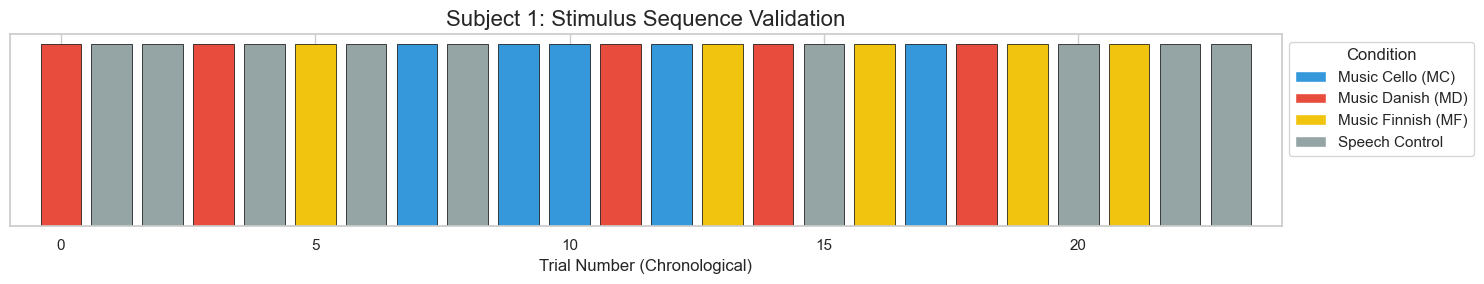

Found 4 distinct conditions.
Total Trials: 24
Consecutive Repeated Conditions: 3
PASSED: Design appears to be interleaved/randomized.


In [ ]:
# Load a representative subject (Subject 1)
sample_subject = os.path.join(data_folder, 'S1_preprocessed.mat')
mat = scipy.io.loadmat(sample_subject)
all_trials = mat['Data'][0, 0]['data'][0]

# Extract the sequence of condition labels
raw_sequence = [t['TargetType'][0] for t in all_trials]

# Map to clean categories
# MC=Cello, MD=Danish, MF=Finnish, S=Speech
audit_map = []
for label in raw_sequence:
    if 'MC' in label: audit_map.append('Music Cello (MC)')
    elif 'MD' in label: audit_map.append('Music Danish (MD)')
    elif 'MF' in label: audit_map.append('Music Finnish (MF)')
    else: audit_map.append('Speech Control')

# VISUAL AUDIT: Timeline of Stimulus Presentation

plt.figure(figsize=(15, 3))
colors = {'Music Cello (MC)': '#3498db', 'Music Danish (MD)': '#e74c3c', 
          'Music Finnish (MF)': '#f1c40f', 'Speech Control': '#95a5a6'}

for i, cond in enumerate(audit_map):
    plt.bar(i, 1, color=colors[cond], width=0.8, edgecolor='black', linewidth=0.5)

plt.title("Subject 1: Stimulus Sequence Validation", fontsize=16)
plt.xlabel("Trial Number (Chronological)", fontsize=12)
plt.yticks([]) # Clean up Y axis
plt.xlim(-1, len(audit_map))

# Add Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left', title="Condition")

plt.tight_layout()
plt.show()

# overall validation for subj 1
consecutive_matches = sum(1 for i in range(len(audit_map)-1) if audit_map[i] == audit_map[i+1])
print(f"Found {len(set(audit_map))} distinct conditions.")
print(f"Total Trials: {len(audit_map)}")
print(f"Consecutive Repeated Conditions: {consecutive_matches}")

if consecutive_matches < (len(audit_map) / 2):
    print("PASSED: Design appears to be interleaved/randomized.")
else:
    print("WARNING: Seems to be a High number of consecutive conditions detected.")

# Methodology & Feature Extraction

Our analysis focuses on the Frequency Domain. We will extract power from the Alpha and Beta bands to calculate the Engagement Index.
- Alpha (8-12 Hz): Inversely related to cognitive processing; increases during relaxation or distraction.
- Beta (13-30 Hz): Associated with active concentration and mental effort.
- Engagement Index: $\text{Engagement} = \frac{\text{Mean Beta Power}}{\text{Mean Alpha Power}}$